# Scanpath similarity & clustering — PoTeC

Examine and measure differences between reading **scanpaths** in `data/potec`, then test
**similarity/distance metrics** and **clustering algorithms** on them.

## What is a scanpath here
A scanpath = the ordered sequence of fixations a reader made on one text. PoTeC's
`eyetracking_data/scanpaths_merged/reader{R}_{domain}{n}_merged_sp_rm.tsv` has **one row per
fixation** (in temporal order). Per fixation we use:

| field | role |
|---|---|
| `word_index_in_text` | AOI (which word was fixated) → symbolic sequence |
| `char_index_in_line` | x position (column, in characters) |
| `line` | y position (text line) |
| `fixation_duration` | dwell time (ms) |

PoTeC has **no raw pixel x/y** in the fixation/scanpath tables — only the word/line grid — so
spatial metrics here operate in *character × line* coordinates (converted to approximate degrees
of visual angle via tunable constants).

## Conventional methods (what the field uses)
`../03-eyebench` does **not** ship a scanpath-similarity utility — it consumes scanpaths only as
token sequences fed to ML models (`pymovements==0.25.0` for preprocessing). The conventional
measures come from the eye-movement literature:

- **ScaSim** (von der Malsburg & Vasishth, 2011, *JML*) — the reading-specific standard.
  Needleman–Wunsch alignment over fixation **position + duration**. Implemented faithfully below.
- **Levenshtein / ScanMatch** — edit distance over the AOI (word) string.
- **DTW** — dynamic time warping over per-fixation feature vectors.
- **MultiMatch** (Dewhurst et al., 2012) — 5-dimensional vector measure (optional; needs
  `pip install multimatch_gaze`).

**Goal:** build distance matrices under each metric, cluster, and check which metric+algorithm
recovers known reader structure (discipline / study level / expert-vs-non-expert reading).

### References
- von der Malsburg & Vasishth (2011) *Scanpaths reveal syntactic underspecification...* JML 65(2). R pkg: https://github.com/tmalsburg/scanpath
- Dewhurst et al. (2012) MultiMatch, *Behavior Research Methods* 44.
- Anderson et al. (2015) *A comparison of scanpath comparison methods.*


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import spearmanr
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.manifold import MDS
from sklearn.metrics import silhouette_score, adjusted_rand_score, adjusted_mutual_info_score

sns.set_context("notebook")
np.random.seed(0)

# --- locate the scanpath dir by walking up from the notebook ---
def find_data_dir():
    here = Path.cwd()
    for base in [here, *here.parents]:
        cand = base / "data" / "potec" / "eyetracking_data" / "scanpaths_merged"
        if cand.is_dir():
            return cand
    raise FileNotFoundError("scanpaths_merged not found above cwd")

DATA_DIR = find_data_dir()
print("data:", DATA_DIR)
print("files:", len(list(DATA_DIR.glob("*.tsv"))))

data: /home/ely/Documents/vault/04-lang-comp-cog/02-project/data/potec/eyetracking_data/scanpaths_merged
files: 900


## Config

To keep pairwise distances tractable (each ScaSim/DTW pair is an `O(L1·L2)` alignment), we study
**one text across a subset of readers** by default. Bump `N_READERS` / loop over `TEXT_ID`s once
you trust the pipeline. `AGGREGATE_WORD=True` collapses consecutive refixations on the same word
(summing their durations) — shortens sequences and speeds alignment.

In [2]:
TEXT_ID        = "b0"     # which text (b0..b5 biology, p0..p5 physics)
N_READERS      = 30       # subset of readers (75 max). C(N,2) alignments per metric.
AGGREGATE_WORD = True     # merge consecutive fixations on the same word

# spatial scaling: char/line grid -> approximate degrees of visual angle (tunable)
DEG_PER_CHAR = 0.28       # ~ one character column
DEG_PER_LINE = 1.30       # ~ one text line
MODULATOR    = 0.83       # ScaSim default

## Load scanpaths

One record per `(reader, text)`: the AOI sequence, raw `(x, y, dur)` for ScaSim, globally
z-scored features for DTW, plus reader metadata used as clustering ground truth.

In [ ]:
META_COLS = ["reader_id","text_id","text_domain","expert_reading_label",
             "reader_discipline_numeric","level_of_studies_numeric","mean_acc_bq"]
USE_COLS  = META_COLS + ["word_index_in_text","char_index_in_line","line",
                         "fixation_duration","fixation_index"]

def load_one(path):
    df = pd.read_csv(path, sep="\t", usecols=USE_COLS)
    df = df.dropna(subset=["word_index_in_text","char_index_in_line","line","fixation_duration"])
    df = df.sort_values("fixation_index")
    if AGGREGATE_WORD:
        # merge runs of consecutive fixations on the same word
        grp = (df["word_index_in_text"] != df["word_index_in_text"].shift()).cumsum()
        df = df.groupby(grp).agg(
            word_index_in_text=("word_index_in_text","first"),
            char_index_in_line=("char_index_in_line","first"),
            line=("line","first"),
            fixation_duration=("fixation_duration","sum"),
        )
    meta = {c: pd.read_csv(path, sep="\t", usecols=[c], nrows=1).iloc[0,0] for c in META_COLS}
    return {
        "id":   f"{meta['reader_id']}|{meta['text_id']}",
        "aoi":  df["word_index_in_text"].to_numpy(int),
        "x":    df["char_index_in_line"].to_numpy(float),
        "y":    df["line"].to_numpy(float),
        "dur":  df["fixation_duration"].to_numpy(float),
        **meta,
    }

# pick TEXT_ID, sampling N_READERS evenly across all readers (reader IDs are grouped
# by discipline, so a spread sample keeps the ground-truth labels balanced)
all_paths = sorted(DATA_DIR.glob(f"reader*_{TEXT_ID}_merged_sp_rm.tsv"),
                   key=lambda p: int(p.name.split("reader")[1].split("_")[0]))
idx = np.unique(np.linspace(0, len(all_paths)-1, min(N_READERS, len(all_paths))).astype(int))
paths = [all_paths[i] for i in idx]
records = [load_one(p) for p in paths]
meta = pd.DataFrame([{k: r[k] for k in ["id"]+META_COLS} for r in records])

# global z-score of (x,y,dur) -> DTW feature vectors
allx = np.concatenate([r["x"] for r in records])
ally = np.concatenate([r["y"] for r in records])
alld = np.concatenate([r["dur"] for r in records])
mu  = np.array([allx.mean(), ally.mean(), alld.mean()])
sd_ = np.array([allx.std(),  ally.std(),  alld.std()]) + 1e-9
for r in records:
    r["feat"] = (np.stack([r["x"], r["y"], r["dur"]], 1) - mu) / sd_

print(f"{len(records)} scanpaths | text={TEXT_ID} | "
      f"len min/median/max = "
      f"{min(len(r['aoi']) for r in records)}/"
      f"{int(np.median([len(r['aoi']) for r in records]))}/"
      f"{max(len(r['aoi']) for r in records)}")
meta.head()

## Metric implementations

All return a **distance** (0 = identical). Covers the classic + recent families:

| metric | family | uses | leakage-safe |
|---|---|---|---|
| `levenshtein` | string edit | AOI (word) order | scale-free |
| `scasim` | reading standard (NW) | position + duration | scale-free |
| `scasim_fix` / `scasim_dur` | reading standard, normalized (ScanDL-style) | scasim ÷ #fix / ÷ Σdur | scale-free |
| `scanmatch` | Levenshtein/NW variant (Cristino 2010, simplified) | spatial substitution score | scale-free |
| `frechet` | SoftMatch core (Newport 2022) | discrete Fréchet on (x,y) | scale-free |
| `dtw` | time-series baseline | z-scored (x,y,dur) | **needs per-fold scaling** |
| `multimatch` | vector, 5-dim (Dewhurst 2012) | shape/dir/len/pos/dur | scale-free |

`scasim` is the reading-research default; `dtw` is a generic baseline, not the field leader.
Semantic-VLM similarity (2026) is omitted — it needs a vision-language model over fixated content.
Everything except `dtw` is scale-free, so only `dtw` is re-scaled per fold in the KNN section.

In [ ]:
def levenshtein(a, b):
    """Edit distance over AOI (word-index) sequences, normalized to [0,1]."""
    a, b = list(a), list(b)
    m, n = len(a), len(b)
    if m == 0 or n == 0:
        return float(max(m, n) > 0)
    prev = np.arange(n + 1, dtype=float)
    for i in range(1, m + 1):
        cur = np.empty(n + 1); cur[0] = i
        for j in range(1, n + 1):
            cost = 0 if a[i-1] == b[j-1] else 1
            cur[j] = min(prev[j] + 1, cur[j-1] + 1, prev[j-1] + cost)
        prev = cur
    return prev[n] / max(m, n)


def scasim(A, B, modulator=MODULATOR,
           deg_per_char=DEG_PER_CHAR, deg_per_line=DEG_PER_LINE):
    """ScaSim (von der Malsburg & Vasishth 2011), faithful to the R `scasim`.

    Substitution cost(i,j) = |dur_i - dur_j| * mixer + (dur_i + dur_j) * (1 - mixer)
    with mixer = modulator ** angle, angle = spatial distance between fixation targets.
    Gap cost = duration of the skipped fixation. Minimized by Needleman-Wunsch DP.

    The original computes `angle` as spherical visual angle from pixel coords; PoTeC has
    only the char/line grid, so we use a planar small-angle approximation in degrees.
    Operates on raw position/duration (scale-free) -> no train/test leakage.
    """
    sx, sy, sd = A["x"]*deg_per_char, A["y"]*deg_per_line, A["dur"]
    tx, ty, td = B["x"]*deg_per_char, B["y"]*deg_per_line, B["dur"]
    m, n = len(sd), len(td)
    if m == 0 or n == 0:
        return float(sd.sum() + td.sum())
    angle = np.sqrt((sx[:,None]-tx[None,:])**2 + (sy[:,None]-ty[None,:])**2)
    mixer = modulator ** angle
    cost  = np.abs(sd[:,None]-td[None,:])*mixer + (sd[:,None]+td[None,:])*(1-mixer)
    d = np.zeros((m+1, n+1))
    d[1:,0] = np.cumsum(sd)
    d[0,1:] = np.cumsum(td)
    for i in range(1, m+1):
        di, dim1 = d[i], d[i-1]
        si = sd[i-1]; ci = cost[i-1]
        for j in range(1, n+1):
            di[j] = min(dim1[j] + si, di[j-1] + td[j-1], dim1[j-1] + ci[j-1])
    return d[m, n]


def scasim_fix(A, B):
    """ScaSim normalized by total #fixations (ScanDL 'ScaSim-Fix')."""
    return scasim(A, B) / (len(A["dur"]) + len(B["dur"]))


def scasim_dur(A, B):
    """ScaSim normalized by total fixation duration (ScanDL 'ScaSim-Dur')."""
    return scasim(A, B) / (A["dur"].sum() + B["dur"].sum())


def scanmatch(A, B, thr_deg=3.0, gap=0.0,
              deg_per_char=DEG_PER_CHAR, deg_per_line=DEG_PER_LINE):
    """ScanMatch-style (Cristino et al. 2010), simplified: Needleman-Wunsch that *maximizes*
    a spatial substitution score sub=(thr-dist)/thr (>0 within thr_deg, <0 beyond). Returned
    as a distance 1 - score/min(len). Keeps ScanMatch's substitution-matrix + alignment idea;
    omits the temporal-binning step (kept O(L^2); duration enters via the other metrics)."""
    sx, sy = A["x"]*deg_per_char, A["y"]*deg_per_line
    tx, ty = B["x"]*deg_per_char, B["y"]*deg_per_line
    m, n = len(sx), len(tx)
    if m == 0 or n == 0:
        return 1.0
    dist = np.sqrt((sx[:,None]-tx[None,:])**2 + (sy[:,None]-ty[None,:])**2)
    sub  = (thr_deg - dist) / thr_deg
    H = np.zeros((m+1, n+1))
    H[1:,0] = np.arange(1, m+1) * gap
    H[0,1:] = np.arange(1, n+1) * gap
    for i in range(1, m+1):
        Hi, Hi1, subi = H[i], H[i-1], sub[i-1]
        for j in range(1, n+1):
            Hi[j] = max(Hi1[j-1] + subi[j-1], Hi1[j] + gap, Hi[j-1] + gap)
    return float(1.0 - H[m, n] / min(m, n))


def _frechet(P, Q):
    """Discrete Frechet distance (coupling distance) between two 2-D point sequences."""
    m, n = len(P), len(Q)
    if m == 0 or n == 0:
        return float("inf")
    d  = np.sqrt(((P[:,None,:] - Q[None,:,:])**2).sum(-1))
    ca = np.empty((m, n))
    ca[0,0] = d[0,0]
    for i in range(1, m): ca[i,0] = max(ca[i-1,0], d[i,0])
    for j in range(1, n): ca[0,j] = max(ca[0,j-1], d[0,j])
    for i in range(1, m):
        for j in range(1, n):
            ca[i,j] = max(min(ca[i-1,j], ca[i-1,j-1], ca[i,j-1]), d[i,j])
    return float(ca[m-1, n-1])


def frechet(A, B, deg_per_char=DEG_PER_CHAR, deg_per_line=DEG_PER_LINE):
    """SoftMatch core: discrete Frechet distance over fixation (x,y) positions."""
    P = np.stack([A["x"]*deg_per_char, A["y"]*deg_per_line], 1)
    Q = np.stack([B["x"]*deg_per_char, B["y"]*deg_per_line], 1)
    return _frechet(P, Q)


def _dtw(P, Q):
    """DTW between two (L, 3) feature matrices, euclidean local cost, length-normalized."""
    m, n = len(P), len(Q)
    if m == 0 or n == 0:
        return float("inf")
    C = np.sqrt(((P[:,None,:] - Q[None,:,:])**2).sum(-1))   # local cost (vectorized)
    d = np.full((m+1, n+1), np.inf); d[0,0] = 0.0
    for i in range(1, m+1):
        di, dim1 = d[i], d[i-1]; ci = C[i-1]
        for j in range(1, n+1):
            di[j] = ci[j-1] + min(dim1[j], di[j-1], dim1[j-1])
    return d[m, n] / (m + n)


def dtw(A, B):
    """DTW over the (x,y,dur) features. `feat` is z-scored; the global scaling in the
    loader is fine for the unsupervised sections (no train/test split). For supervised
    KNN-CV the scaler is re-fit per training fold instead (see the classification cell)."""
    return _dtw(A["feat"], B["feat"])


METRICS = {"levenshtein": lambda a,b: levenshtein(a["aoi"], b["aoi"]),
           "scasim":     scasim,
           "scasim_fix": scasim_fix,
           "scasim_dur": scasim_dur,
           "scanmatch":  scanmatch,
           "frechet":    frechet,
           "dtw":        dtw}

# MultiMatch (5-dim vector measure) -- optional dependency
try:
    import multimatch_gaze as _mmg
    _SCREEN = [float(np.concatenate([r["x"] for r in records]).max()) + 1,
               float(np.concatenate([r["y"] for r in records]).max()) + 1]
    def _mm_vec(R):
        return np.rec.fromarrays([R["x"], R["y"], R["dur"]],
                                 names=["start_x", "start_y", "duration"])
    def multimatch(A, B):
        """1 - mean of MultiMatch's 5 similarity dimensions (shape/dir/len/pos/dur)."""
        sims = _mmg.docomparison(_mm_vec(A), _mm_vec(B), screensize=_SCREEN)
        return float(1.0 - np.nanmean(sims))
    METRICS["multimatch"] = multimatch
    print("MultiMatch enabled | screensize(char,line) =", _SCREEN)
except Exception as e:
    print("MultiMatch unavailable (pip install multimatch_gaze):", e)

print("metrics:", list(METRICS))

## Pairwise distance matrices

In [5]:
def pairwise(records, fn):
    N = len(records)
    D = np.zeros((N, N))
    for i in range(N):
        for j in range(i+1, N):
            D[i,j] = D[j,i] = fn(records[i], records[j])
    return D

import time
DIST = {}
for name, fn in METRICS.items():
    t0 = time.time()
    DIST[name] = pairwise(records, fn)
    print(f"{name:12s} {time.time()-t0:5.1f}s  "
          f"range [{DIST[name][np.triu_indices(len(records),1)].min():.3g}, "
          f"{DIST[name][np.triu_indices(len(records),1)].max():.3g}]")

levenshtein    5.5s  range [0.348, 0.923]
scasim         6.5s  range [2.55e+04, 2.3e+05]
dtw            4.8s  range [0.167, 1.12]


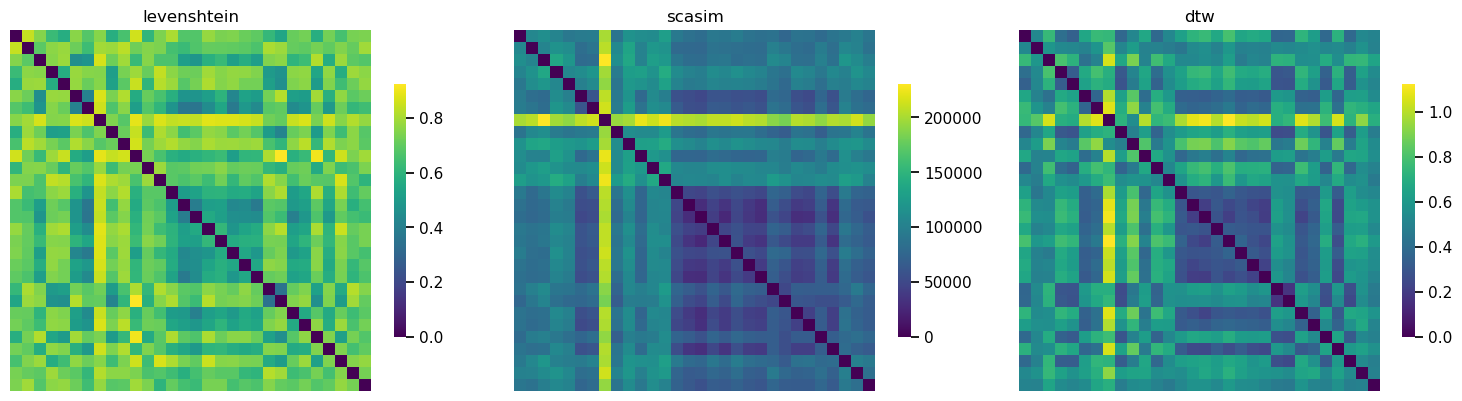

In [6]:
fig, axes = plt.subplots(1, len(DIST), figsize=(5*len(DIST), 4))
for ax, (name, D) in zip(np.atleast_1d(axes), DIST.items()):
    sns.heatmap(D, ax=ax, cmap="viridis", square=True, cbar_kws={"shrink":.7})
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## Do the metrics agree?
Spearman correlation between the off-diagonal entries of each distance matrix (Mantel-style).
Low agreement ⇒ the metrics capture different aspects of the scanpaths.

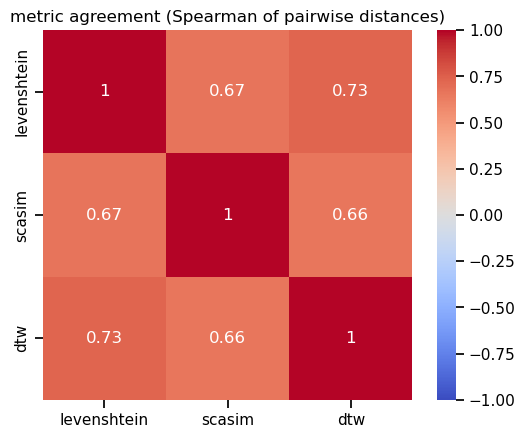

In [7]:
names = list(DIST)
iu = np.triu_indices(len(records), 1)
agree = np.eye(len(names))
for a in range(len(names)):
    for b in range(a+1, len(names)):
        rho = spearmanr(DIST[names[a]][iu], DIST[names[b]][iu]).correlation
        agree[a,b] = agree[b,a] = rho
sns.heatmap(pd.DataFrame(agree, index=names, columns=names),
            annot=True, vmin=-1, vmax=1, cmap="coolwarm", square=True)
plt.title("metric agreement (Spearman of pairwise distances)"); plt.show()

## Clustering

Three families on each precomputed distance matrix:
- **Hierarchical** (scipy `average` linkage) + dendrogram
- **Agglomerative** (sklearn, `metric='precomputed'`)
- **DBSCAN** (density, `metric='precomputed'`)
- **KMeans** on a 2-D **MDS** embedding of the distances

Ground-truth labels to compare against (clustering is unsupervised — we only *score* against these):

In [8]:
LABELS = {
    "discipline":   meta["reader_discipline_numeric"].to_numpy(),
    "study_level":  meta["level_of_studies_numeric"].to_numpy(),
    "expert_read":  (meta["expert_reading_label"] == "expert_reading").astype(int).to_numpy(),
}
K = max(2, max(len(np.unique(v)) for v in LABELS.values()))   # default cluster count (>=2)
print("k =", K, "| label balance:")
for n,v in LABELS.items():
    print(" ", n, dict(zip(*np.unique(v, return_counts=True))))

k = 2 | label balance:
  discipline {np.int64(0): np.int64(17), np.int64(1): np.int64(13)}
  study_level {np.int64(0): np.int64(10), np.int64(1): np.int64(20)}
  expert_read {np.int64(0): np.int64(19), np.int64(1): np.int64(11)}


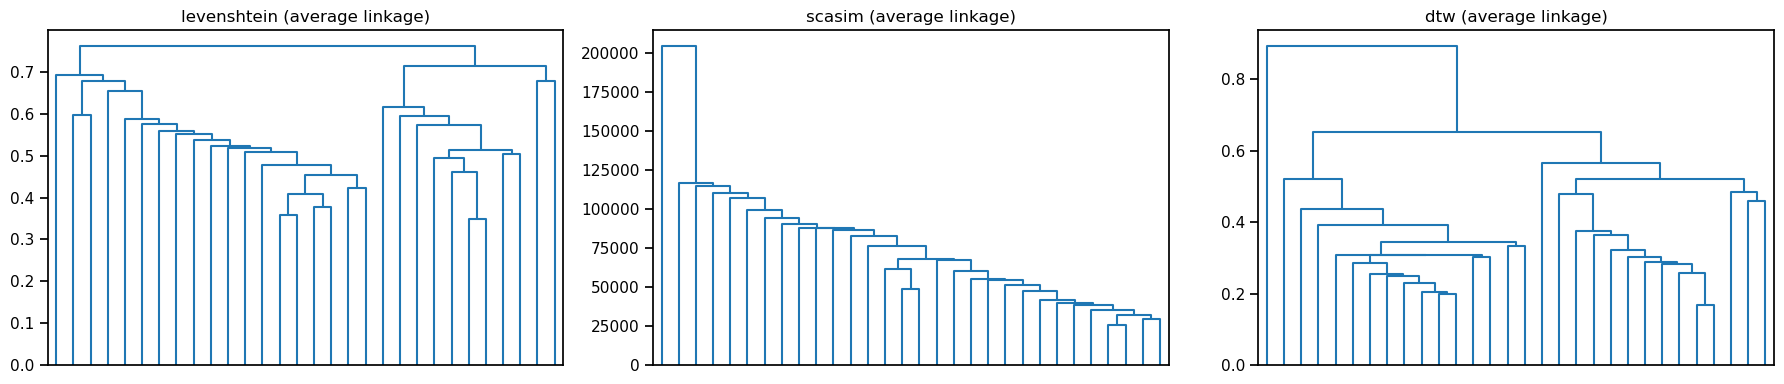

In [9]:
# dendrograms per metric
fig, axes = plt.subplots(1, len(DIST), figsize=(6*len(DIST), 4))
LINKS = {}
for ax, (name, D) in zip(np.atleast_1d(axes), DIST.items()):
    Z = linkage(squareform(D, checks=False), method="average")
    LINKS[name] = Z
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=0)
    ax.set_title(f"{name} (average linkage)")
plt.tight_layout(); plt.show()

In [10]:
def cluster_all(D, k):
    out = {}
    out["hierarchical"] = fcluster(linkage(squareform(D, checks=False), "average"),
                                   k, criterion="maxclust")
    out["agglomerative"] = AgglomerativeClustering(
        n_clusters=k, metric="precomputed", linkage="average").fit_predict(D)
    # DBSCAN eps from the median off-diagonal distance
    eps = np.median(D[np.triu_indices(len(D),1)])
    out["dbscan"] = DBSCAN(eps=eps, min_samples=3, metric="precomputed").fit_predict(D)
    emb = MDS(n_components=2, dissimilarity="precomputed",
              random_state=0, normalized_stress="auto").fit_transform(D)
    out["kmeans_mds"] = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(emb)
    return out, emb

CLUST, EMB = {}, {}
for name, D in DIST.items():
    CLUST[name], EMB[name] = cluster_all(D, K)

## Evaluation

- **Silhouette** (precomputed distances) — internal cohesion/separation, no labels needed.
- **ARI / AMI** vs each ground-truth label — does the partition recover known reader structure?

In [11]:
rows = []
for metric, D in DIST.items():
    iu_ = np.triu_indices(len(D),1)
    for algo, lab in CLUST[metric].items():
        valid = len(set(lab)) > 1 and len(set(lab)) < len(lab)
        sil = silhouette_score(D, lab, metric="precomputed") if valid else np.nan
        row = {"metric":metric, "algo":algo, "n_clusters":len(set(lab)), "silhouette":sil}
        for lname, lv in LABELS.items():
            row[f"ARI_{lname}"] = adjusted_rand_score(lv, lab)
            row[f"AMI_{lname}"] = adjusted_mutual_info_score(lv, lab)
        rows.append(row)
res = pd.DataFrame(rows)
res.round(3)

,metric,algo,n_clusters,silhouette,ARI_discipline,AMI_discipline,ARI_study_level,AMI_study_level,ARI_expert_read,AMI_expert_read
0,levenshtein,hierarchical,2,0.220,0.081,0.048,-0.019,-0.027,0.005,0.043
1,levenshtein,agglomerative,2,0.220,0.081,0.048,-0.019,-0.027,0.005,0.043
2,levenshtein,dbscan,1,NaN,0.000,0.000,0.000,0.000,0.000,0.000
3,levenshtein,kmeans_mds,2,0.214,0.039,0.020,0.006,-0.012,0.039,0.067
4,scasim,hierarchical,2,0.568,0.021,0.013,-0.033,-0.022,-0.028,-0.018
5,scasim,agglomerative,2,0.568,0.021,0.013,-0.033,-0.022,-0.028,-0.018
6,scasim,dbscan,2,0.348,0.138,0.202,0.155,0.073,-0.056,0.092
7,scasim,kmeans_mds,2,0.207,0.081,0.048,-0.019,-0.027,0.005,0.043
8,dtw,hierarchical,2,0.367,0.021,0.013,-0.033,-0.022,-0.028,-0.018
9,dtw,agglomerative,2,0.367,0.021,0.013,-0.033,-0.022,-0.028,-0.018


In [12]:
# best metric+algo per ground-truth label (by ARI)
for lname in LABELS:
    best = res.sort_values(f"ARI_{lname}", ascending=False).iloc[0]
    print(f"{lname:12s} best ARI={best[f'ARI_{lname}']:.3f}  "
          f"via {best['metric']}+{best['algo']}")

discipline   best ARI=0.138  via scasim+dbscan
study_level  best ARI=0.155  via scasim+dbscan
expert_read  best ARI=0.192  via dtw+kmeans_mds


## Visualize — MDS embedding
Rows = metrics. Left column colored by **KMeans cluster**, remaining columns by each
**ground-truth label**. Tight, label-aligned color groups ⇒ that metric separates readers the way
the label does.

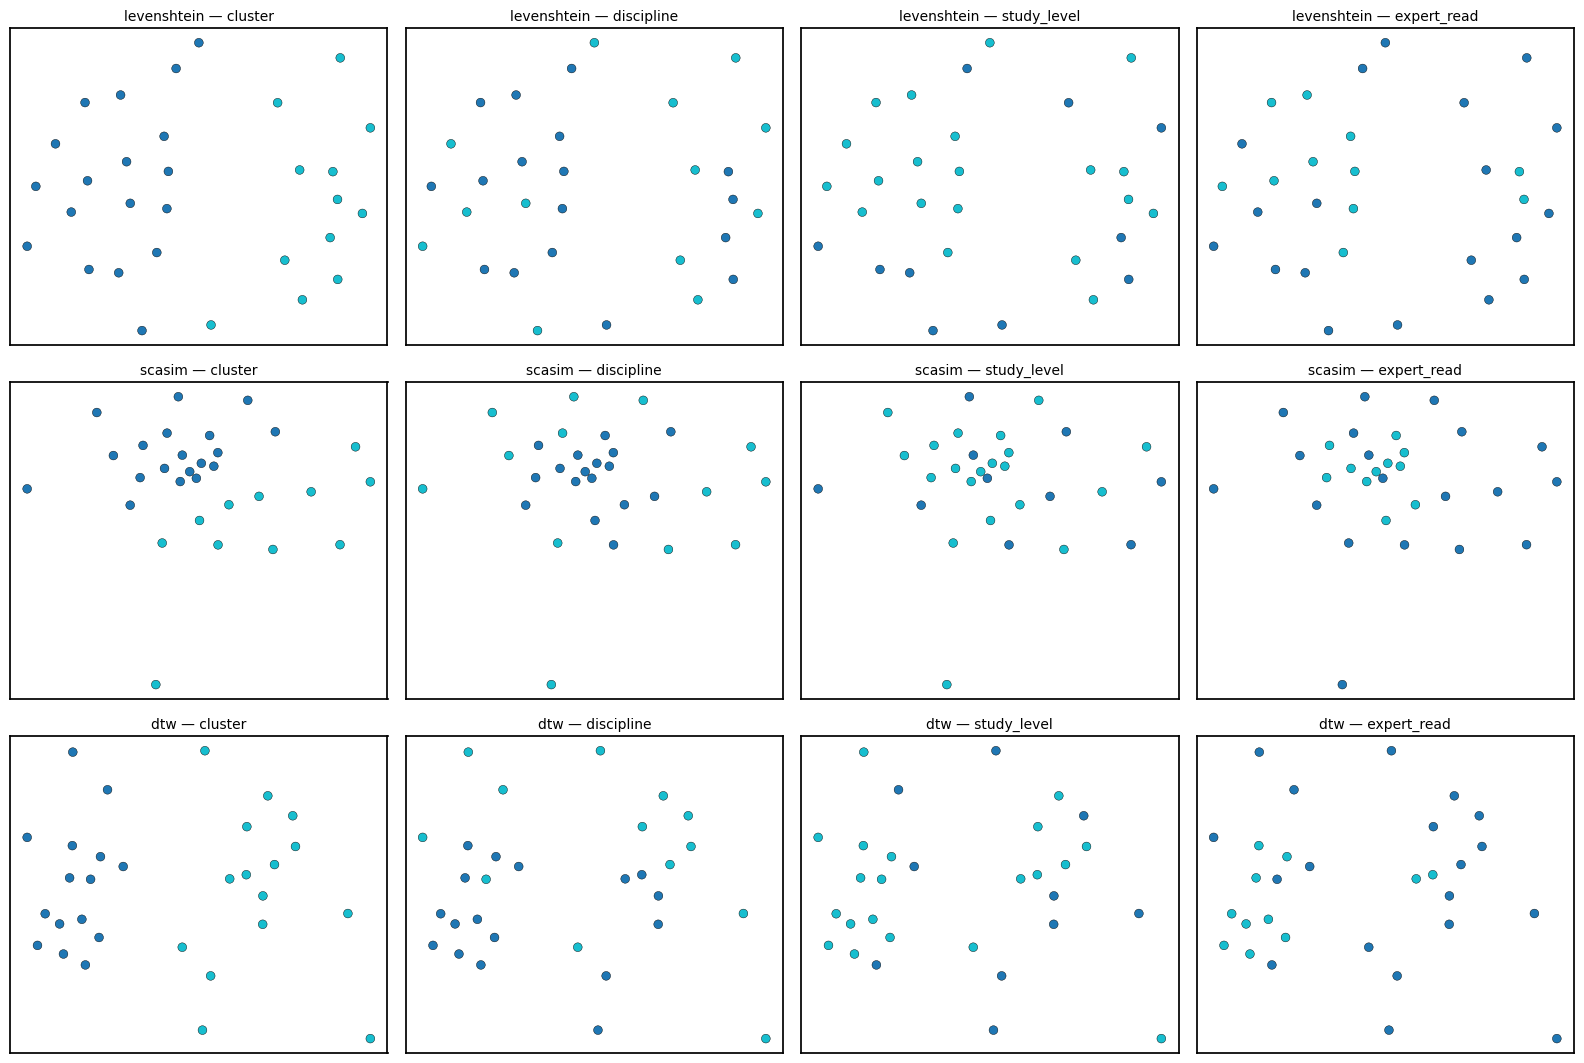

In [13]:
ncol = 1 + len(LABELS)
fig, axes = plt.subplots(len(DIST), ncol, figsize=(4*ncol, 3.6*len(DIST)), squeeze=False)
for r,(metric, emb) in enumerate(EMB.items()):
    panels = [("cluster", CLUST[metric]["kmeans_mds"])] + list(LABELS.items())
    for c,(title, lab) in enumerate(panels):
        ax = axes[r][c]
        ax.scatter(emb[:,0], emb[:,1], c=lab, cmap="tab10", s=40, edgecolor="k", lw=.3)
        ax.set_title(f"{metric} — {title}", fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## Extending this

- **More texts / all readers:** loop `TEXT_ID` over `b0..p5`, raise `N_READERS` to 75. Aggregate
  per-text distance matrices (e.g. average) before clustering readers globally.
- **k sweep:** loop `K` and plot silhouette vs k to choose cluster count per metric.
- **MultiMatch:** `pip install multimatch_gaze`; feed it `(x, y, dur)` arrays per scanpath to add
  its 5 dimensions (shape/direction/length/position/duration) as extra distance matrices.
- **ScanMatch:** substitution-matrix variant of Levenshtein — swap the 0/1 cost in `levenshtein`
  for a word-distance / position-aware score.
- **Speed:** the ScaSim/DTW DP inner loop is the bottleneck. For full corpus, `numba.njit` the DP
  or drop `AGGREGATE_WORD=True` sequences into a Cython kernel.

## 2-D scanpath map by text domain

Project scanpaths into 2-D and plot **physics texts** and **biology texts** in separate panels;
each dot is one scanpath, colored by the **reader's discipline** (physics vs biology — `reader_discipline_numeric`, 0=biology / 1=physics per CODEBOOK).

**Reduction:** ScaSim distances are non-Euclidean (alignment cost, not coordinates), so the
appropriate reduction is **metric MDS on the precomputed distance matrix** — it places scanpaths so
2-D distances best preserve ScaSim dissimilarities. (For a neighborhood-focused view, swap in
`TSNE(metric="precomputed", init="random")` or UMAP.)

If physics-discipline dots separate from biology-discipline dots *within a panel*, reader expertise
leaves a scanpath signature on that text domain.

In [14]:
# load a corpus spanning both text domains (physics texts p*, biology texts b*)
PHYS_TEXTS = ["p0", "p1"]      # which physics texts to pool
BIO_TEXTS  = ["b0", "b1"]      # which biology texts to pool
DOMAIN_TEXTS = {"physics": PHYS_TEXTS, "biology": BIO_TEXTS}

def load_text(text_id, n_readers):
    ap = sorted(DATA_DIR.glob(f"reader*_{text_id}_merged_sp_rm.tsv"),
                key=lambda p: int(p.name.split("reader")[1].split("_")[0]))
    sel = np.unique(np.linspace(0, len(ap)-1, min(n_readers, len(ap))).astype(int))
    return [load_one(ap[i]) for i in sel]

DOMAIN_CORPUS = {}             # text-domain -> list of scanpath records (readers x its texts)
for dom, texts in DOMAIN_TEXTS.items():
    recs = []
    for t in texts:
        recs += load_text(t, N_READERS)
    DOMAIN_CORPUS[dom] = recs
    disc = np.array([r["reader_discipline_numeric"] for r in recs])
    print(f"{dom:8s}: {len(recs):3d} scanpaths | "
          f"readers bio={int((disc==0).sum())} phys={int((disc==1).sum())}")

physics :  60 scanpaths | readers bio=34 phys=26
biology :  60 scanpaths | readers bio=34 phys=26


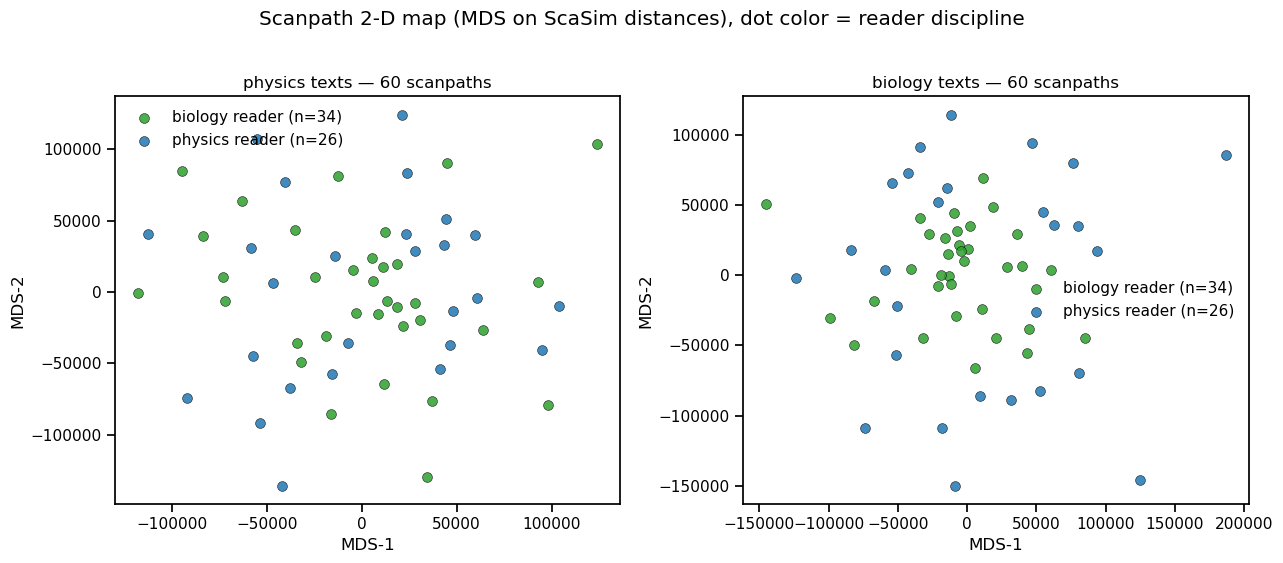

In [15]:
# --- embed each domain group in 2-D (MDS on ScaSim distances) and scatter ---
DISC_NAME  = {0: "biology", 1: "physics"}          # reader_discipline_numeric (CODEBOOK)
DISC_COLOR = {0: "tab:green", 1: "tab:blue"}

fig, axes = plt.subplots(1, len(DOMAIN_CORPUS), figsize=(6.5*len(DOMAIN_CORPUS), 5.5),
                         squeeze=False)
for ax, (dom, recs) in zip(axes[0], DOMAIN_CORPUS.items()):
    D = pairwise(recs, scasim)                      # scanpath distance within this text domain
    emb = MDS(n_components=2, dissimilarity="precomputed", random_state=0,
              normalized_stress="auto").fit_transform(D)
    disc = np.array([r["reader_discipline_numeric"] for r in recs])
    for d in (0, 1):
        m = disc == d
        ax.scatter(emb[m,0], emb[m,1], c=DISC_COLOR[d], s=50, edgecolor="k", lw=.4,
                   alpha=.85, label=f"{DISC_NAME[d]} reader (n={m.sum()})")
    ax.set_title(f"{dom} texts — {len(recs)} scanpaths")
    ax.set_xlabel("MDS-1"); ax.set_ylabel("MDS-2"); ax.legend(frameon=False)
fig.suptitle("Scanpath 2-D map (MDS on ScaSim distances), dot color = reader discipline",
             y=1.02)
plt.tight_layout(); plt.show()

## KNN domain classification (cross-validated)

Predict each reader's **discipline** (biology vs physics) from their scanpath, using a
**distance-weighted KNN** on the scanpath distances (one text → one scanpath per reader, so a
row = a reader; no same-reader leakage).

**Class imbalance** (the corpus has more biology than physics readers) is handled at three levels:
1. **`StratifiedKFold`** — every fold keeps the population class ratio.
2. **Majority undersampling inside each training fold** — biology readers are randomly downsampled
   to the physics count (1:1), so KNN's neighbor vote isn't biased toward the majority. Done on the
   *training* split only; the test split stays untouched/representative.
3. **Imbalance-aware metrics** — raw accuracy is misleading here (predict-all-biology already
   scores the majority rate), so we report **balanced accuracy**, **macro-F1**, and **per-class
   recall**, plus a **row-normalized confusion matrix** (diagonal = recall per class).

**No scaling leakage.** dtw needs feature z-scoring, so the scaler `(mu, sd)` is **fit on the
training fold only** and then applied to the held-out test scanpaths — dtw distances are therefore
**recomputed inside every fold** (`fold_distances`), never read from the globally-scaled matrix.
scasim (raw position/duration) and levenshtein (symbolic) are scale-free, so their precomputed
matrices are sliced directly. (The global `DIST["dtw"]` is still fine for the *unsupervised*
clustering/MDS sections, which have no train/test split.)

CV is repeated `N_REPEATS` times (different random folds + undersampling draws) and averaged
(mean ± std). A majority-class baseline is included for reference.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, recall_score, confusion_matrix)

K_NEIGHBORS = 5      # neighbors (clamped to balanced train size per fold)
N_SPLITS    = 5      # stratified folds
N_REPEATS   = 10     # repeat CV (random folds + undersampling) -> stable estimates

y = LABELS["discipline"].astype(int)        # 0 = biology reader, 1 = physics reader
CLASSES = np.array([0, 1])

def balance_idx(tr, y, rng):
    """Undersample the majority class within the training fold to 1:1."""
    n = np.bincount(y[tr], minlength=2).min()
    return np.concatenate([rng.choice(tr[y[tr] == c], n, replace=False) for c in CLASSES])

def fold_distances(metric, records, tr, te):
    """Distances (D_train_train, D_test_train) with scaling fit on TRAIN only.

    dtw needs feature z-scoring; the scaler (mu, sd) is learned from the training fixations
    and then applied to the test fixations -> no leakage. scasim/levenshtein are scale-free,
    so we just slice their precomputed matrices.
    """
    if metric == "dtw":
        xs = np.concatenate([records[i]["x"]   for i in tr])
        ys = np.concatenate([records[i]["y"]   for i in tr])
        ds = np.concatenate([records[i]["dur"] for i in tr])
        mu = np.array([xs.mean(), ys.mean(), ds.mean()])
        sd = np.array([xs.std(),  ys.std(),  ds.std()]) + 1e-9   # learned on TRAIN
        def feat(i):
            r = records[i]
            return (np.stack([r["x"], r["y"], r["dur"]], 1) - mu) / sd  # applied everywhere
        ftr = [feat(i) for i in tr]; fte = [feat(i) for i in te]
        Dtt  = np.array([[_dtw(p, q) for q in ftr] for p in ftr])
        Dtet = np.array([[_dtw(p, q) for q in ftr] for p in fte])
        return Dtt, Dtet
    D = DIST[metric]
    return D[np.ix_(tr, tr)], D[np.ix_(te, tr)]

def knn_cv(metric, records, y, k=K_NEIGHBORS, n_splits=N_SPLITS, n_repeats=N_REPEATS):
    accs, baccs, f1s, recs, cms = [], [], [], [], []
    for rep in range(n_repeats):
        rng = np.random.default_rng(rep)
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=rep)
        pred = np.empty_like(y)
        for tr, te in skf.split(np.zeros((len(y), 1)), y):
            trb = balance_idx(tr, y, rng)                 # rebalanced TRAIN only
            Dtt, Dtet = fold_distances(metric, records, trb, te)   # scaler fit on trb
            clf = KNeighborsClassifier(n_neighbors=min(k, len(trb)),
                                       metric="precomputed", weights="distance")
            clf.fit(Dtt, y[trb])
            pred[te] = clf.predict(Dtet)                  # test rows x train cols
        accs.append(accuracy_score(y, pred))
        baccs.append(balanced_accuracy_score(y, pred))
        f1s.append(f1_score(y, pred, average="macro"))
        recs.append(recall_score(y, pred, average=None, labels=CLASSES))
        cms.append(confusion_matrix(y, pred, labels=CLASSES))
    return dict(acc=accs, bacc=baccs, f1=f1s, recs=np.array(recs), cm=np.mean(cms, 0))

def ms(a):  # mean +/- std formatter
    return f"{np.mean(a):.3f} ± {np.std(a):.3f}"

RESULTS, summary = {}, []
maj = np.bincount(y).max() / len(y)
summary.append({"metric": "baseline (majority)", "accuracy": f"{maj:.3f}",
                "bal_accuracy": "0.500", "f1_macro": "-",
                "recall_biology": "-", "recall_physics": "-"})
for name in DIST:
    r = knn_cv(name, records, y); RESULTS[name] = r
    summary.append({"metric": name, "accuracy": ms(r["acc"]),
                    "bal_accuracy": ms(r["bacc"]), "f1_macro": ms(r["f1"]),
                    "recall_biology": f"{r['recs'][:,0].mean():.3f}",
                    "recall_physics": f"{r['recs'][:,1].mean():.3f}"})
print(f"N={len(y)} readers | biology={int((y==0).sum())} physics={int((y==1).sum())} "
      f"| {N_SPLITS}-fold x {N_REPEATS} repeats, majority-undersampled train, "
      f"dtw scaler fit per fold")
pd.DataFrame(summary)

In [ ]:
# row-normalized confusion matrices (diagonal = per-class recall -> imbalance-robust)
fig, axes = plt.subplots(1, len(RESULTS), figsize=(4*len(RESULTS), 3.5), squeeze=False)
for ax, (name, r) in zip(axes[0], RESULTS.items()):
    cm = r["cm"]; cmn = cm / cm.sum(1, keepdims=True)
    sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=False,
                xticklabels=["biology","physics"], yticklabels=["biology","physics"], ax=ax)
    ax.set_title(f"{name}\nbal-acc {np.mean(r['bacc']):.2f}")
    ax.set_xlabel("predicted reader discipline"); ax.set_ylabel("true")
fig.suptitle("KNN domain classification — mean confusion (row-normalized)", y=1.04)
plt.tight_layout(); plt.show()

## EyeBench-style DE task: multi-text, generalization regimes

Re-frame the classifier to match `../03-eyebench`'s **PoTeC Domain-Expertise (DE)** task and protocol:

- **Target = DE**, defined exactly as EyeBench: `DE = (mean_acc_bq > 0.9)` — High(1) if the reader
  aced the text's background-knowledge questions, else Low(0). This is a **per-trial behavioral
  label** (reader × paragraph), not the reader's demographic discipline.
- **Multiple texts**, pooled as per-trial samples (one row = one reader reading one paragraph).
- **Three generalization regimes** (4 grouped folds each), matching EyeBench:
  `seen_subject_unseen_item` (new texts), `unseen_subject_seen_item` (new readers),
  `unseen_subject_unseen_item` (both new).
- **Metrics: AUROC + balanced accuracy** (EyeBench's classification metrics), vs a 0.5 baseline.
- **Metrics under test: `scasim_dur`, `scasim_fix`, `dtw`** only. Base ScaSim is computed once and
  the two normalizations derived from it; dtw is re-scaled per training fold (leak-free).

**Caveats.** (1) ScaSim/DTW compare fixation *positions*; across **different paragraphs** (the
`unseen_item` regimes) layouts differ, so a distance-to-neighbors classifier is on weak ground
there — expect it near baseline. EyeBench's per-trial feature models don't share this limit.
(2) This replicates the *protocol* on our raw loader, not EyeBench's harmonized folds, so numbers
are indicative, not leaderboard-exact. (3) Small default corpus → noisy; raise `N_READERS_DE` /
`TEXTS_DE` (slower: dtw recomputes distances every fold).

In [ ]:
# --- multi-text per-trial corpus for the DE task ---
TEXTS_DE     = ["b0", "b1", "p0", "p1"]   # paragraphs pooled (mix biology + physics)
N_READERS_DE = 20                         # readers per text

records_de = []
for t in TEXTS_DE:
    records_de += load_text(t, N_READERS_DE)

subj_de = np.array([r["reader_id"] for r in records_de])              # generalization group: reader
item_de = np.array([r["text_id"]   for r in records_de])              # generalization group: text
y_de    = np.array([int(r["mean_acc_bq"] > 0.9) for r in records_de]) # DE: High(1)/Low(0)

# precompute base ScaSim ONCE, then derive the two normalized variants (scale-free -> no leakage)
N = len(records_de)
base = np.zeros((N, N))
for i in range(N):
    for j in range(i+1, N):
        base[i, j] = base[j, i] = scasim(records_de[i], records_de[j])
nfix = np.array([len(r["dur"]) for r in records_de], float)
dsum = np.array([r["dur"].sum() for r in records_de], float)
D_dur = base / (dsum[:, None] + dsum[None, :]); np.fill_diagonal(D_dur, 0.0)
D_fix = base / (nfix[:, None] + nfix[None, :]); np.fill_diagonal(D_fix, 0.0)
DIST_DE = {"scasim_dur": D_dur, "scasim_fix": D_fix}   # dtw recomputed per fold (below)

hi = int(y_de.sum())
print(f"{N} trials | {len(set(subj_de))} readers x {len(TEXTS_DE)} texts {TEXTS_DE}")
print(f"DE label: High={hi} ({hi/N:.0%})  Low={N-hi}")

In [ ]:
# EyeBench-style evaluation: 3 generalization regimes x 4 folds, AUROC + balanced accuracy
from sklearn.metrics import roc_auc_score

REGIMES_DE  = ["seen_subject_unseen_item",
               "unseen_subject_seen_item",
               "unseen_subject_unseen_item"]
N_SPLITS_DE = 4      # EyeBench uses 4 folds
N_REPEATS_DE = 3     # repeats (random group->fold + undersampling); raise for stability (slower)
K_DE        = 5

def make_folds(subj, item, y, regime, n_splits, rng):
    """Yield (train_idx, test_idx) for one generalization regime (grouped CV)."""
    def fold_map(vals):
        parts = np.array_split(rng.permutation(np.unique(vals)), n_splits)
        m = {v: k for k, p in enumerate(parts) for v in p}
        return np.array([m[v] for v in vals])
    sf, itf = fold_map(subj), fold_map(item)
    idx = np.arange(len(subj))
    for k in range(n_splits):
        if regime == "unseen_subject_seen_item":
            te, tr = idx[sf == k], idx[sf != k]
        elif regime == "seen_subject_unseen_item":
            te, tr = idx[itf == k], idx[itf != k]
        else:  # unseen_subject_unseen_item: both reader and text held out
            te, tr = idx[(sf == k) & (itf == k)], idx[(sf != k) & (itf != k)]
        if len(te) and len(np.unique(y[tr])) == 2:
            yield tr, te

def de_fold_dist(metric, recs, tr, te):
    """(D_train_train, D_test_train); dtw scaler fit on TRAIN fold only (leak-free)."""
    if metric == "dtw":
        sd = np.array([np.concatenate([recs[i][a] for i in tr]).std()
                       for a in ("x", "y", "dur")]) + 1e-9          # mu cancels in diffs
        feat = lambda i: np.stack([recs[i]["x"], recs[i]["y"], recs[i]["dur"]], 1) / sd
        ftr, fte = [feat(i) for i in tr], [feat(i) for i in te]
        return (np.array([[_dtw(p, q) for q in ftr] for p in ftr]),
                np.array([[_dtw(p, q) for q in ftr] for p in fte]))
    D = DIST_DE[metric]
    return D[np.ix_(tr, tr)], D[np.ix_(te, tr)]

def eval_regime(metric, regime):
    aurocs, baccs = [], []
    for rep in range(N_REPEATS_DE):
        rng = np.random.default_rng(rep)
        tt, pp, pr = [], [], []
        for tr, te in make_folds(subj_de, item_de, y_de, regime, N_SPLITS_DE, rng):
            trb = balance_idx(tr, y_de, rng)
            Dtt, Dtet = de_fold_dist(metric, records_de, trb, te)
            clf = KNeighborsClassifier(n_neighbors=min(K_DE, len(trb)),
                                       metric="precomputed", weights="distance").fit(Dtt, y_de[trb])
            tt.append(y_de[te]); pp.append(clf.predict(Dtet)); pr.append(clf.predict_proba(Dtet)[:, 1])
        tt, pp, pr = np.concatenate(tt), np.concatenate(pp), np.concatenate(pr)
        if len(np.unique(tt)) == 2:
            aurocs.append(roc_auc_score(tt, pr))
            baccs.append(balanced_accuracy_score(tt, pp))
    return (np.mean(aurocs), np.std(aurocs), np.mean(baccs), np.std(baccs)) if aurocs else (np.nan,)*4

rows = []
for metric in ["scasim_dur", "scasim_fix", "dtw"]:
    row = {"metric": metric}
    for regime in REGIMES_DE:
        a, asd, b, bsd = eval_regime(metric, regime)
        short = regime.replace("_subject", "-subj").replace("_item", "-item")
        row[f"{short} AUROC"]  = f"{a:.3f}±{asd:.3f}"
        row[f"{short} balAcc"] = f"{b:.3f}±{bsd:.3f}"
    rows.append(row)
print(f"DE task | {len(records_de)} trials | majority baseline: AUROC 0.500, balAcc 0.500")
pd.DataFrame(rows)